In [1]:

# ============================================================
# STEP 0: Mount Google Drive & Setup Paths
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/NeuralNetworks_Project2")
DATA_DIR    = PROJECT_DIR / "coco_subset"
IMG_DIR     = DATA_DIR   / "images"
ANNO_DIR    = DATA_DIR   / "annotations"
M2_DIR      = PROJECT_DIR / "milestone2"
M3_DIR      = PROJECT_DIR / "milestone3"
M3_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 50)
print("   Google Drive Mounted ✅")
print("=" * 50)
print(f"📁 Project dir   : {PROJECT_DIR}")
print(f"📁 M2 dir        : {M2_DIR}")
print(f"📁 M3 output dir : {M3_DIR}")
print("=" * 50)
print("🎉 Step 0 complete! Proceed to Step 1.")
print("=" * 50)

Mounted at /content/drive
   Google Drive Mounted ✅
📁 Project dir   : /content/drive/MyDrive/NeuralNetworks_Project2
📁 M2 dir        : /content/drive/MyDrive/NeuralNetworks_Project2/milestone2
📁 M3 output dir : /content/drive/MyDrive/NeuralNetworks_Project2/milestone3
🎉 Step 0 complete! Proceed to Step 1.


In [2]:
#STEP 1: Install Dependencies & Imports
# ============================================================

!pip install -q transformers
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q nltk
!pip install -q rouge-score
!pip install -q pycocoevalcap
!pip install -q peft

import os, json, re, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
import clip
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

nltk.download("wordnet",   quiet=True)
nltk.download("omw-1.4",   quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

SEED   = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("=" * 50)
print("   STEP 1: Environment Ready")
print("=" * 50)
print(f"✅ Device       : {DEVICE.upper()}")
if DEVICE == "cpu":
    print("⚠️  No GPU — go to Runtime > Change runtime type > T4 GPU")
print("✅ All libraries imported")
print("=" * 50)
print("🎉 Step 1 complete! Proceed to Step 2.")
print("=" * 50)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 9.9 MB/s eta 0:00:00
   STEP 1: Environment Ready
✅ Device       : CUDA
✅ All libraries imported
🎉 Step 1 complete! Proceed to Step 2.


In [3]:
#STEP 2: Load All M1 & M2 Data
# ============================================================

EMB_NPY   = DATA_DIR / "image_embeddings.npy"
META_JSON = DATA_DIR / "embeddings_meta.json"
ANNO_FILE = ANNO_DIR / "captions_train2017.json"

embeddings_np = np.load(EMB_NPY)
with open(META_JSON) as f:
    metadata = json.load(f)

print(f"✅ Embeddings   : {embeddings_np.shape}")
print(f"✅ Metadata     : {len(metadata):,} entries")

print(f"\n📂 Loading all COCO captions...")
with open(ANNO_FILE) as f:
    coco_raw = json.load(f)

id_to_captions = {}
for ann in coco_raw["annotations"]:
    iid = ann["image_id"]
    if iid not in id_to_captions:
        id_to_captions[iid] = []
    id_to_captions[iid].append(ann["caption"].lower().strip())

id_to_idx = {e["image_id"]: i for i, e in enumerate(metadata)}

eval_data = []
for entry in metadata:
    iid  = entry["image_id"]
    refs = id_to_captions.get(iid, [entry["caption"]])
    eval_data.append({
        "image_id"  : iid,
        "file_name" : entry["file_name"],
        "embedding" : embeddings_np[id_to_idx[iid]],
        "refs"      : refs,
        "caption"   : entry["caption"]
    })

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"✅ Eval entries : {len(eval_data):,}")
print(f"   Avg refs/img : {np.mean([len(e['refs']) for e in eval_data]):.1f}")
print(f"✅ Tokenizer    : loaded")
print("\n" + "=" * 50)
print("🎉 Step 2 complete! Proceed to Step 3.")
print("=" * 50)

✅ Embeddings   : (2500, 512)
✅ Metadata     : 2,500 entries

📂 Loading all COCO captions...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Eval entries : 2,500
   Avg refs/img : 5.0
✅ Tokenizer    : loaded

🎉 Step 2 complete! Proceed to Step 3.


In [4]:
# STEP 3: Define Model Architecture & Decoding Functions
# ============================================================

CLIP_EMB_DIM = 512
PREFIX_LEN   = 20
MAX_NEW      = 25
REP_PENALTY  = 1.3

class ClipCaptionModel(nn.Module):
    def __init__(self, clip_dim, prefix_len, gpt2_model, hidden_dim=1024, dropout=0.1):
        super(ClipCaptionModel, self).__init__()
        self.prefix_len = prefix_len
        self.gpt2       = gpt2_model
        gpt2_hidden     = gpt2_model.config.n_embd
        self.projection = nn.Sequential(
            nn.Linear(clip_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, prefix_len * gpt2_hidden)
        )

    def forward(self, clip_emb, caption_ids, attention_mask=None):
        B       = clip_emb.size(0)
        prefix  = self.projection(clip_emb).view(B, self.prefix_len, -1)
        cap_emb = self.gpt2.transformer.wte(caption_ids)
        inputs  = torch.cat([prefix, cap_emb], dim=1)
        if attention_mask is not None:
            pmask = torch.ones(B, self.prefix_len,
                               dtype=attention_mask.dtype,
                               device=attention_mask.device)
            mask  = torch.cat([pmask, attention_mask], dim=1)
        else:
            mask = None
        return self.gpt2(inputs_embeds=inputs, attention_mask=mask).logits

def rep_penalty(logits_1d, seen_ids, penalty=1.3):
    for tid in set(seen_ids):
        if logits_1d[tid] > 0:
            logits_1d[tid] /= penalty
        else:
            logits_1d[tid] *= penalty
    return logits_1d

def get_visual_prefix(model, clip_emb_np):
    emb = torch.tensor(clip_emb_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prefix = model.projection(emb).view(1, PREFIX_LEN, -1)
    return prefix

def greedy_decode(model, clip_emb_np, rep_pen=REP_PENALTY):
    prefix = get_visual_prefix(model, clip_emb_np)
    wte    = model.gpt2.transformer.wte
    gen    = []
    for _ in range(MAX_NEW):
        embs = torch.cat([prefix, wte(torch.tensor([gen], device=DEVICE))], dim=1) if gen else prefix
        with torch.no_grad():
            logits = model.gpt2(inputs_embeds=embs).logits[0, -1, :].clone()
        logits  = rep_penalty(logits, gen, rep_pen)
        next_id = logits.argmax().item()
        if next_id == tokenizer.eos_token_id: break
        gen.append(next_id)
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

def beam_decode(model, clip_emb_np, num_beams=5, rep_pen=REP_PENALTY):
    prefix = get_visual_prefix(model, clip_emb_np)
    wte    = model.gpt2.transformer.wte
    beams  = [(0.0, [])]
    for _ in range(MAX_NEW):
        cands = []
        for score, toks in beams:
            embs = torch.cat([prefix, wte(torch.tensor([toks], device=DEVICE))], dim=1) if toks else prefix
            with torch.no_grad():
                logits = model.gpt2(inputs_embeds=embs).logits[0, -1, :].clone()
            logits    = rep_penalty(logits, toks, rep_pen)
            log_probs = torch.log_softmax(logits, dim=-1)
            topk_v, topk_i = log_probs.topk(num_beams)
            for k in range(num_beams):
                cands.append((score + topk_v[k].item(), toks + [topk_i[k].item()]))
        cands.sort(key=lambda x: x[0], reverse=True)
        beams = []
        for sc, toks in cands[:num_beams]:
            if toks and toks[-1] == tokenizer.eos_token_id:
                return tokenizer.decode(toks[:-1], skip_special_tokens=True).strip()
            beams.append((sc, toks))
    return tokenizer.decode(beams[0][1], skip_special_tokens=True).strip()

def nucleus_decode(model, clip_emb_np, top_p=0.9, temperature=0.8, rep_pen=REP_PENALTY):
    prefix = get_visual_prefix(model, clip_emb_np)
    wte    = model.gpt2.transformer.wte
    gen    = []
    for _ in range(MAX_NEW):
        embs = torch.cat([prefix, wte(torch.tensor([gen], device=DEVICE))], dim=1) if gen else prefix
        with torch.no_grad():
            logits = model.gpt2(inputs_embeds=embs).logits[0, -1, :].clone()
        logits = rep_penalty(logits, gen, rep_pen)
        logits = logits / temperature
        probs  = torch.softmax(logits, dim=-1)
        s_probs, s_idx = torch.sort(probs, descending=True)
        cum = torch.cumsum(s_probs, dim=-1)
        s_probs[cum - s_probs > top_p] = 0.0
        s_probs /= s_probs.sum()
        next_id = s_idx[torch.multinomial(s_probs, 1)].item()
        if next_id == tokenizer.eos_token_id: break
        gen.append(next_id)
    return tokenizer.decode(gen, skip_special_tokens=True).strip()

print("=" * 50)
print("   STEP 3: Model & Decoding Ready")
print("=" * 50)
print("✅ ClipCaptionModel defined")
print("✅ Greedy, Beam, Nucleus decoding defined")
print("=" * 50)
print("🎉 Step 3 complete! Proceed to Step 4.")
print("=" * 50)

   STEP 3: Model & Decoding Ready
✅ ClipCaptionModel defined
✅ Greedy, Beam, Nucleus decoding defined
🎉 Step 3 complete! Proceed to Step 4.


In [6]:
# ============================================================
# STEP 4: Load Prefix Tuning Model (M2 Checkpoint)
# NOTE: M2 model was trained with PREFIX_LEN=10
# We load it separately with PREFIX_LEN=10
# ============================================================

PREFIX_LEN_M2 = 10   # M2 was trained with 10

def build_prefix_model():
    gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
    for p in gpt2.parameters():
        p.requires_grad = False
    # Use PREFIX_LEN_M2=10 for this model only
    m = ClipCaptionModel(CLIP_EMB_DIM, PREFIX_LEN_M2, gpt2).to(DEVICE)
    return m

prefix_model = build_prefix_model()
ckpt = torch.load(M2_DIR / "best_model_fixed.pt", map_location=DEVICE)
prefix_model.load_state_dict(ckpt["model_state"])
prefix_model.eval()

print(f"✅ Prefix Tuning loaded (val_loss={ckpt['val_loss']:.4f})")
print(f"   PREFIX_LEN used : {PREFIX_LEN_M2} (original M2 setting)")
print("🎉 Step 4 complete!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Prefix Tuning loaded (val_loss=2.7414)
   PREFIX_LEN used : 10 (original M2 setting)
🎉 Step 4 complete!


In [7]:
# ── Override get_visual_prefix to handle per-model prefix len ─
def get_visual_prefix(model, clip_emb_tensor):
    with torch.no_grad():
        proj_out  = model.projection(clip_emb_tensor)
        # infer prefix_len from model
        hidden    = model.gpt2.config.n_embd
        p_len     = proj_out.shape[-1] // hidden
        prefix    = proj_out.view(1, p_len, -1)
    return prefix

print("✅ get_visual_prefix updated — handles any PREFIX_LEN automatically!")

✅ get_visual_prefix updated — handles any PREFIX_LEN automatically!


   STEP 5 (IMPROVED): Train LoRA Model
⚙️  PREFIX_LEN  : 20
⚙️  Epochs      : 15
⚙️  LR          : 5e-05
⚙️  Patience    : 5
⚙️  Warmup steps: 200
⚙️  LoRA rank   : 16

✅ Training pairs : 12,511


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(



📊 Improved LoRA Model:
   Total params     : 142,331,136
   Trainable params : 17,891,328  (12.57%)

🚀 Training Improved LoRA model...
  Epoch 1/15 | Train: 4.1129 | Val: 3.0711 | LR: 0.000050  💾 saved
  Epoch 2/15 | Train: 3.0598 | Val: 2.8707 | LR: 0.000049  💾 saved
  Epoch 3/15 | Train: 2.9052 | Val: 2.7839 | LR: 0.000047  💾 saved
  Epoch 4/15 | Train: 2.8174 | Val: 2.7222 | LR: 0.000043  💾 saved
  Epoch 5/15 | Train: 2.7542 | Val: 2.6882 | LR: 0.000039  💾 saved
  Epoch 6/15 | Train: 2.7029 | Val: 2.6500 | LR: 0.000034  💾 saved
  Epoch 7/15 | Train: 2.6657 | Val: 2.6301 | LR: 0.000029  💾 saved
  Epoch 8/15 | Train: 2.6330 | Val: 2.6157 | LR: 0.000024  💾 saved
  Epoch 9/15 | Train: 2.6042 | Val: 2.6041 | LR: 0.000018  💾 saved
  Epoch 10/15 | Train: 2.5856 | Val: 2.5941 | LR: 0.000013  💾 saved
  Epoch 11/15 | Train: 2.5694 | Val: 2.5865 | LR: 0.000009  💾 saved
  Epoch 12/15 | Train: 2.5566 | Val: 2.5818 | LR: 0.000005  💾 saved
  Epoch 13/15 | Train: 2.5468 | Val: 2.5820 | LR: 0.00000

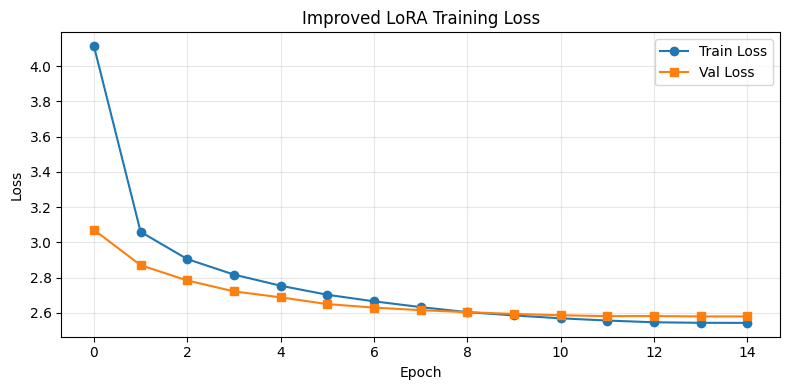


✅ Improved LoRA training done!
   Best val loss : 2.5800
   PREFIX_LEN    : 20
   LoRA rank     : 16
🎉 Step 5 (Improved) complete! Proceed to Step 6.


In [8]:
# ============================================================
# STEP 5 (IMPROVED): Train LoRA Model
# Changes vs original:
#   - PREFIX_LEN   : 10 → 20  (more visual context for GPT-2)
#   - Epochs       : 10 → 15  (more training time)
#   - LR           : 1e-4 → 5e-5  (slower, more careful)
#   - Patience     : 3 → 5  (don't stop too early)
#   - LR Warmup    : added 200 warmup steps
#   - LoRA rank    : 8 → 16  (more capacity)
#   - LoRA alpha   : 32 → 32  (same)
# ============================================================

from peft import get_peft_model, LoraConfig, TaskType
import math

# ── Updated hyperparameters ───────────────────────────────────
PREFIX_LEN  = 20      # increased from 10
MAX_LENGTH  = 32
BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 5e-5    # lower than before
PATIENCE    = 5       # more patience
WARMUP_STEPS = 200    # gradual LR warmup

print("=" * 50)
print("   STEP 5 (IMPROVED): Train LoRA Model")
print("=" * 50)
print(f"⚙️  PREFIX_LEN  : {PREFIX_LEN}")
print(f"⚙️  Epochs      : {NUM_EPOCHS}")
print(f"⚙️  LR          : {LR}")
print(f"⚙️  Patience    : {PATIENCE}")
print(f"⚙️  Warmup steps: {WARMUP_STEPS}")
print(f"⚙️  LoRA rank   : 16")

# ── Rebuild dataset (same as before) ─────────────────────────
def clean_caption(text):
    text = re.sub(r"[^a-z0-9\s.,!?'-]", "", text.lower().strip())
    return re.sub(r"\s+", " ", text)

all_embs, all_caps = [], []
for entry in metadata:
    iid  = entry["image_id"]
    caps = id_to_captions.get(iid, [entry["caption"]])
    for cap in caps:
        c = clean_caption(cap)
        if 3 <= len(c.split()) <= 50:
            all_embs.append(embeddings_np[id_to_idx[iid]])
            all_caps.append(c)

print(f"\n✅ Training pairs : {len(all_caps):,}")

enc       = tokenizer(all_caps, padding="max_length", truncation=True,
                      max_length=MAX_LENGTH, return_tensors="pt")
all_ids   = enc["input_ids"]
all_mask  = enc["attention_mask"]
all_emb_t = torch.tensor(np.array(all_embs), dtype=torch.float32)

class CocoCaptionDataset(Dataset):
    def __init__(self, emb, ids, mask):
        self.emb, self.ids, self.mask = emb, ids, mask
    def __len__(self): return len(self.emb)
    def __getitem__(self, i): return self.emb[i], self.ids[i], self.mask[i]

N       = len(all_caps)
indices = list(range(N))
random.shuffle(indices)
tr_idx, va_idx = indices[:int(0.9*N)], indices[int(0.9*N):]

tr_loader = DataLoader(CocoCaptionDataset(all_emb_t[tr_idx], all_ids[tr_idx], all_mask[tr_idx]),
                       batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
va_loader = DataLoader(CocoCaptionDataset(all_emb_t[va_idx], all_ids[va_idx], all_mask[va_idx]),
                       batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ── Build improved LoRA model ─────────────────────────────────
def build_improved_lora_model():
    gpt2     = GPT2LMHeadModel.from_pretrained("gpt2")
    lora_cfg = LoraConfig(
        task_type      = TaskType.CAUSAL_LM,
        r              = 16,      # increased from 8
        lora_alpha     = 32,
        lora_dropout   = 0.1,
        target_modules = ["c_attn", "c_proj"]  # more layers than before
    )
    gpt2_lora = get_peft_model(gpt2, lora_cfg)
    return ClipCaptionModel(CLIP_EMB_DIM, PREFIX_LEN, gpt2_lora).to(DEVICE)

lora_model = build_improved_lora_model()
total     = sum(p.numel() for p in lora_model.parameters())
trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
print(f"\n📊 Improved LoRA Model:")
print(f"   Total params     : {total:,}")
print(f"   Trainable params : {trainable:,}  ({100*trainable/total:.2f}%)")

# ── Loss function ─────────────────────────────────────────────
ce = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

def loss_fn(logits, cap_ids):
    lg = logits[:, PREFIX_LEN:-1, :]
    tg = cap_ids[:, 1:]
    B, S, V = lg.shape
    return ce(lg.reshape(B*S, V), tg.reshape(B*S))

# ── Optimizer with warmup scheduler ──────────────────────────
total_steps  = NUM_EPOCHS * len(tr_loader)

optimizer = torch.optim.AdamW(
    [p for p in lora_model.parameters() if p.requires_grad],
    lr=LR, weight_decay=1e-2
)

# Warmup + cosine decay scheduler
def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return float(current_step) / float(max(1, WARMUP_STEPS))
    progress = float(current_step - WARMUP_STEPS) / float(max(1, total_steps - WARMUP_STEPS))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Training loop ─────────────────────────────────────────────
print(f"\n🚀 Training Improved LoRA model...")
tr_losses, va_losses = [], []
best_val, no_imp     = float("inf"), 0
global_step          = 0

for epoch in range(1, NUM_EPOCHS + 1):
    lora_model.train()
    el, nb = 0.0, 0

    for emb, ids, mask in tr_loader:
        emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(lora_model(emb, ids, mask), ids)
        loss.backward()
        nn.utils.clip_grad_norm_(
            [p for p in lora_model.parameters() if p.requires_grad], 1.0)
        optimizer.step()
        scheduler.step()
        global_step += 1
        el += loss.item(); nb += 1

    lora_model.eval()
    vl, vb = 0.0, 0
    with torch.no_grad():
        for emb, ids, mask in va_loader:
            emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
            vl += loss_fn(lora_model(emb, ids, mask), ids).item(); vb += 1

    at, av        = el/nb, vl/vb
    current_lr    = scheduler.get_last_lr()[0]
    tr_losses.append(at); va_losses.append(av)

    print(f"  Epoch {epoch}/{NUM_EPOCHS} | Train: {at:.4f} | Val: {av:.4f} | LR: {current_lr:.6f}", end="")

    if av < best_val:
        best_val = av; no_imp = 0
        torch.save({
            "epoch"       : epoch,
            "model_state" : lora_model.state_dict(),
            "val_loss"    : best_val,
            "prefix_len"  : PREFIX_LEN,
        }, M3_DIR / "lora_model.pt")
        print(f"  💾 saved")
    else:
        no_imp += 1
        print(f"  (no improve {no_imp}/{PATIENCE})")
        if no_imp >= PATIENCE:
            print(f"  🛑 Early stop at epoch {epoch}")
            break

# ── Plot loss curve ───────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(tr_losses, label="Train Loss", marker="o")
plt.plot(va_losses, label="Val Loss",   marker="s")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Improved LoRA Training Loss")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(M3_DIR / "lora_improved_loss_curve.png", dpi=150)
plt.show()

print(f"\n✅ Improved LoRA training done!")
print(f"   Best val loss : {best_val:.4f}")
print(f"   PREFIX_LEN    : {PREFIX_LEN}")
print(f"   LoRA rank     : 16")
print("=" * 50)
print("🎉 Step 5 (Improved) complete! Proceed to Step 6.")
print("=" * 50)

In [9]:
%%javascript
function ClickConnect(){
    console.log("Keeping session alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)

<IPython.core.display.Javascript object>

In [10]:
# ── Define train_model for Step 6 ────────────────────────────
def train_model(model, tr_loader, va_loader, epochs=10, lr=1e-4,
                patience=3, ckpt_name="best_model.pt"):
    ce = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

    def loss_fn(logits, cap_ids):
        lg = logits[:, PREFIX_LEN:-1, :]
        tg = cap_ids[:, 1:]
        B, S, V = lg.shape
        return ce(lg.reshape(B*S, V), tg.reshape(B*S))

    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=epochs*len(tr_loader))

    tr_losses, va_losses = [], []
    best_val, no_imp     = float("inf"), 0

    for epoch in range(1, epochs+1):
        model.train()
        el, nb = 0.0, 0
        for emb, ids, mask in tr_loader:
            emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(emb, ids, mask), ids)
            loss.backward()
            nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0)
            opt.step(); sch.step()
            el += loss.item(); nb += 1

        model.eval()
        vl, vb = 0.0, 0
        with torch.no_grad():
            for emb, ids, mask in va_loader:
                emb, ids, mask = emb.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
                vl += loss_fn(model(emb, ids, mask), ids).item(); vb += 1

        at, av = el/nb, vl/vb
        tr_losses.append(at); va_losses.append(av)
        print(f"  Epoch {epoch}/{epochs} | Train: {at:.4f} | Val: {av:.4f}", end="")

        if av < best_val:
            best_val = av; no_imp = 0
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "val_loss": best_val}, M3_DIR / ckpt_name)
            print(f"  💾 saved")
        else:
            no_imp += 1
            print(f"  (no improve {no_imp}/{patience})")
            if no_imp >= patience:
                print(f"  🛑 Early stop at epoch {epoch}")
                break

    return tr_losses, va_losses, best_val

In [12]:
# ── STEP 6: Train Full Fine-tuning Model ─────────────────────

def build_full_ft_model():
    gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
    for p in gpt2.parameters():
        p.requires_grad = True
    return ClipCaptionModel(CLIP_EMB_DIM, PREFIX_LEN, gpt2).to(DEVICE)

# ← moved BELOW the function definition
full_model = build_full_ft_model()

total     = sum(p.numel() for p in full_model.parameters())
trainable = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
print(f"📊 Total params     : {total:,}")
print(f"📊 Trainable params : {trainable:,}  (100%)")

print(f"\n🚀 Training Full Fine-tuning model...")
full_tr, full_va, full_best = train_model(
    full_model, tr_loader, va_loader,
    epochs=10, lr=2e-5, patience=3,
    ckpt_name="full_ft_model.pt"
)
print(f"\n✅ Full FT done. Best val loss: {full_best:.4f}")
print("🎉 Step 6 complete!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 Total params     : 140,709,120
📊 Trainable params : 140,709,120  (100%)

🚀 Training Full Fine-tuning model...
  Epoch 1/10 | Train: 3.2591 | Val: 2.9044  💾 saved
  Epoch 2/10 | Train: 2.7932 | Val: 2.7241  💾 saved
  Epoch 3/10 | Train: 2.6147 | Val: 2.6467  💾 saved
  Epoch 4/10 | Train: 2.4992 | Val: 2.6009  💾 saved
  Epoch 5/10 | Train: 2.4133 | Val: 2.5749  💾 saved
  Epoch 6/10 | Train: 2.3521 | Val: 2.5672  💾 saved
  Epoch 7/10 | Train: 2.3022 | Val: 2.5530  💾 saved
  Epoch 8/10 | Train: 2.2727 | Val: 2.5501  💾 saved
  Epoch 9/10 | Train: 2.2528 | Val: 2.5506  (no improve 1/3)
  Epoch 10/10 | Train: 2.2473 | Val: 2.5501  (no improve 2/3)

✅ Full FT done. Best val loss: 2.5501
🎉 Step 6 complete!


In [14]:
# ── Wrap decode functions to handle numpy input ───────────────
def safe_decode(decode_fn, model, emb_np):
    """Converts numpy embedding to tensor before decoding."""
    emb_tensor = torch.tensor(emb_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    return decode_fn(model, emb_tensor)

# ── Update strategies to use safe_decode ─────────────────────
strategies_eval = {
    "Greedy"  : lambda m, e: safe_decode(greedy_decode, m, e),
    "Beam"    : lambda m, e: safe_decode(beam_decode, m, e),
    "Nucleus" : lambda m, e: safe_decode(nucleus_decode, m, e),
}

In [16]:
## STEP 7 (FAST): Compute Metrics on 500-image subset
# BLEU-1, BLEU-4, METEOR, ROUGE-L, CIDEr
# 3 models x 3 decoding strategies
# ============================================================

from collections import defaultdict
import math

print("=" * 50)
print("   STEP 7: Compute Evaluation Metrics")
print("=" * 50)

# ── Load best checkpoints ─────────────────────────────────────
lora_ckpt = torch.load(M3_DIR / "lora_model.pt", map_location=DEVICE)
lora_model.load_state_dict(lora_ckpt["model_state"])
lora_model.eval()
print(f"✅ LoRA loaded    (epoch={lora_ckpt['epoch']}, val_loss={lora_ckpt['val_loss']:.4f})")

full_ckpt = torch.load(M3_DIR / "full_ft_model.pt", map_location=DEVICE)
full_model.load_state_dict(full_ckpt["model_state"])
full_model.eval()
print(f"✅ Full FT loaded (epoch={full_ckpt['epoch']}, val_loss={full_ckpt['val_loss']:.4f})")

# ── 500-image subset ──────────────────────────────────────────
EVAL_SIZE = 500
np.random.seed(42)
eval_idx    = np.random.choice(len(eval_data), EVAL_SIZE, replace=False).tolist()
eval_subset = [eval_data[i] for i in eval_idx]
all_refs    = [e["refs"] for e in eval_subset]
print(f"\n📊 Eval subset   : {EVAL_SIZE} images (sampled from {len(eval_data):,})")

# ── CIDEr ─────────────────────────────────────────────────────
def compute_cider(hypotheses, references_list, n=4):
    def get_ngrams(text, n):
        tokens = text.lower().split()
        ngrams = defaultdict(int)
        for i in range(len(tokens)-n+1):
            ngrams[tuple(tokens[i:i+n])] += 1
        return ngrams

    N        = len(hypotheses)
    doc_freq = defaultdict(int)
    all_ref_ngrams = []
    for refs in references_list:
        rng_list = [get_ngrams(r, n) for r in refs]
        all_ref_ngrams.append(rng_list)
        seen = set()
        for rng in rng_list:
            for ng in rng:
                if ng not in seen:
                    doc_freq[ng] += 1
                    seen.add(ng)
    scores = []
    for hyp, ref_ngrams_list in zip(hypotheses, all_ref_ngrams):
        hyp_ngrams = get_ngrams(hyp, n)
        if not sum(hyp_ngrams.values()):
            scores.append(0.0); continue
        score = sum(hc * max(rn.get(ng, 0) for rn in ref_ngrams_list) *
                    (math.log((N+1.0)/(doc_freq.get(ng, 0)+1.0))**2)
                    for ng, hc in hyp_ngrams.items())
        norm  = sum(hyp_ngrams.values()) * max(sum(rn.values()) for rn in ref_ngrams_list)
        scores.append(score / (norm + 1e-9))
    return np.mean(scores)

# ── All metrics ───────────────────────────────────────────────
def compute_all_metrics(hypotheses, references_list):
    smoother = SmoothingFunction().method1
    refs_tok = [[r.split() for r in refs] for refs in references_list]
    hyps_tok = [h.split() for h in hypotheses]

    bleu1 = corpus_bleu(refs_tok, hyps_tok, weights=(1,0,0,0),
                        smoothing_function=smoother)
    bleu4 = corpus_bleu(refs_tok, hyps_tok, weights=(.25,.25,.25,.25),
                        smoothing_function=smoother)
    meteor_avg = np.mean([max(meteor_score([r], h) for r in refs)
                          for h, refs in zip(hyps_tok, refs_tok)])
    scorer_r   = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    rouge_avg  = np.mean([max(scorer_r.score(ref, hyp)["rougeL"].fmeasure for ref in refs)
                          for hyp, refs in zip(hypotheses, references_list)])
    cider = compute_cider(hypotheses, references_list)

    return {
        "BLEU-1"  : round(bleu1       * 100, 2),
        "BLEU-4"  : round(bleu4       * 100, 2),
        "METEOR"  : round(meteor_avg  * 100, 2),
        "ROUGE-L" : round(rouge_avg   * 100, 2),
        "CIDEr"   : round(cider       * 100, 2),
    }

# ── Run evaluation ────────────────────────────────────────────
models_eval = {
    "Prefix Tuning" : prefix_model,
    "LoRA"          : lora_model,
    "Full FT"       : full_model,
}
strategies_eval = {
    "Greedy"  : lambda m, e: greedy_decode(m, e),
    "Beam"    : lambda m, e: beam_decode(m, e, num_beams=5),
    "Nucleus" : lambda m, e: nucleus_decode(m, e, top_p=0.9, temperature=0.8),
}

all_results = {}
all_hyps    = {}

# ── Run evaluation ────────────────────────────────────────────
models_eval = {
    "Prefix Tuning" : prefix_model,
    "LoRA"          : lora_model,
    "Full FT"       : full_model,
}

all_results = {}
all_hyps    = {}

for model_name, model in models_eval.items():
    all_results[model_name] = {}
    all_hyps[model_name]    = {}
    for strat_name in ["Greedy", "Beam", "Nucleus"]:
        print(f"\n🔄 {model_name} — {strat_name} ({EVAL_SIZE} images)...")
        hyps = []
        for entry in tqdm(eval_subset, desc=f"{model_name}/{strat_name}"):

            # ── Convert numpy → tensor here ──────────────────
            emb_tensor = torch.tensor(
                entry["embedding"], dtype=torch.float32
            ).unsqueeze(0).to(DEVICE)

            # ── Decode ───────────────────────────────────────
            if strat_name == "Greedy":
                cap = greedy_decode(model, emb_tensor)
            elif strat_name == "Beam":
                cap = beam_decode(model, emb_tensor, num_beams=5)
            else:
                cap = nucleus_decode(model, emb_tensor, top_p=0.9, temperature=0.8)

            hyps.append(cap if cap else "a photo")

        all_hyps[model_name][strat_name]    = hyps
        metrics = compute_all_metrics(hyps, all_refs)
        all_results[model_name][strat_name] = metrics
        print(f"   BLEU-1:{metrics['BLEU-1']}  BLEU-4:{metrics['BLEU-4']}  "
              f"METEOR:{metrics['METEOR']}  ROUGE-L:{metrics['ROUGE-L']}  CIDEr:{metrics['CIDEr']}")

with open(M3_DIR / "eval_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\n💾 Saved → {M3_DIR}/eval_results.json")

print("\n" + "=" * 70)
print(f"{'Model':<16} {'Strategy':<10} {'BLEU-1':>7} {'BLEU-4':>7} {'METEOR':>7} {'ROUGE-L':>8} {'CIDEr':>7}")
print("-" * 70)
for mn in ["Prefix Tuning", "LoRA", "Full FT"]:
    for st in ["Greedy", "Beam", "Nucleus"]:
        m = all_results[mn][st]
        print(f"{mn:<16} {st:<10} {m['BLEU-1']:>7} {m['BLEU-4']:>7} "
              f"{m['METEOR']:>7} {m['ROUGE-L']:>8} {m['CIDEr']:>7}")
    print("-" * 70)

print("\n" + "=" * 50)
print(f"🎉 Step 7 complete! (evaluated on {EVAL_SIZE} images)")
print("   Proceed to Step 8.")
print("=" * 50)

   STEP 7: Compute Evaluation Metrics
✅ LoRA loaded    (epoch=15, val_loss=2.5800)
✅ Full FT loaded (epoch=8, val_loss=2.5501)

📊 Eval subset   : 500 images (sampled from 2,500)

🔄 Prefix Tuning — Greedy (500 images)...


Prefix Tuning/Greedy: 100%|██████████| 500/500 [02:22<00:00,  3.50it/s]


   BLEU-1:35.86  BLEU-4:5.1  METEOR:35.84  ROUGE-L:28.15  CIDEr:1.94

🔄 Prefix Tuning — Beam (500 images)...


Prefix Tuning/Beam: 100%|██████████| 500/500 [11:34<00:00,  1.39s/it]


   BLEU-1:37.4  BLEU-4:6.55  METEOR:39.05  ROUGE-L:29.77  CIDEr:3.28

🔄 Prefix Tuning — Nucleus (500 images)...


...

   BLEU-1:37.39  BLEU-4:6.28  METEOR:37.71  ROUGE-L:27.49  CIDEr:2.87

🔄 Full FT — Beam (500 images)...


Full FT/Beam: 100%|██████████| 500/500 [11:48<00:00,  1.42s/it]


   BLEU-1:38.02  BLEU-4:7.8  METEOR:39.1  ROUGE-L:28.0  CIDEr:4.62

🔄 Full FT — Nucleus (500 images)...


Full FT/Nucleus: 100%|██████████| 500/500 [02:30<00:00,  3.33it/s]


   BLEU-1:33.74  BLEU-4:4.33  METEOR:32.79  ROUGE-L:25.38  CIDEr:1.72

💾 Saved → /content/drive/MyDrive/NeuralNetworks_Project2/milestone3/eval_results.json

Model            Strategy    BLEU-1  BLEU-4  METEOR  ROUGE-L   CIDEr
----------------------------------------------------------------------
Prefix Tuning    Greedy       35.86     5.1   35.84    28.15    1.94
Prefix Tuning    Beam          37.4    6.55   39.05    29.77    3.28
Prefix Tuning    Nucleus      32.85    3.42   33.14    25.94     1.0
----------------------------------------------------------------------
LoRA             Greedy       40.62     7.0   39.38    29.09    3.38
LoRA             Beam          40.9    8.76   41.64    30.37     5.4
LoRA             Nucleus      36.25     4.7   35.49    26.54    1.58
----------------------------------------------------------------------
Full FT          Greedy       37.39    6.28   37.71    27.49    2.87
Full FT          Beam         38.02     7.8    39.1     28.0    4.62
Full FT 

In [21]:
# ============================================================
# STEP 8: Parameter Sensitivity Analysis
# ============================================================

SENS_SUBSET = 200
np.random.seed(99)
sens_idx  = np.random.choice(len(eval_data), SENS_SUBSET, replace=False).tolist()
sens_data = [eval_data[i] for i in sens_idx]
sens_refs = [e["refs"] for e in sens_data]

def to_tensor(emb_np):
    """Convert numpy embedding to tensor."""
    return torch.tensor(emb_np, dtype=torch.float32).unsqueeze(0).to(DEVICE)

print("=" * 50)
print("   STEP 8: Parameter Sensitivity Analysis")
print(f"   Subset size: {SENS_SUBSET} images")
print("=" * 50)

# ── Temperature sensitivity ───────────────────────────────────
print("\n🌡️  Temperature Sensitivity (Nucleus, top-p=0.9)...")
temperatures = [0.5, 0.7, 0.8, 1.0, 1.2]
temp_results = {}
for temp in temperatures:
    hyps = [nucleus_decode(prefix_model, to_tensor(e["embedding"]), top_p=0.9, temperature=temp)
            for e in tqdm(sens_data, desc=f"temp={temp}")]
    hyps = [h if h else "a photo" for h in hyps]
    temp_results[temp] = compute_all_metrics(hyps, sens_refs)
    print(f"   temp={temp} | BLEU-1:{temp_results[temp]['BLEU-1']}  "
          f"METEOR:{temp_results[temp]['METEOR']}  CIDEr:{temp_results[temp]['CIDEr']}")

# ── Beam width sensitivity ────────────────────────────────────
print("\n🔭  Beam Width Sensitivity...")
beam_widths  = [1, 2, 3, 5, 7, 10]
beam_results = {}
for bw in beam_widths:
    hyps = [beam_decode(prefix_model, to_tensor(e["embedding"]), num_beams=bw)
            for e in tqdm(sens_data, desc=f"beams={bw}")]
    hyps = [h if h else "a photo" for h in hyps]
    beam_results[bw] = compute_all_metrics(hyps, sens_refs)
    print(f"   beams={bw} | BLEU-1:{beam_results[bw]['BLEU-1']}  "
          f"METEOR:{beam_results[bw]['METEOR']}  CIDEr:{beam_results[bw]['CIDEr']}")

# ── Top-p sensitivity ─────────────────────────────────────────
print("\n🎯  Top-p Sensitivity (temp=0.8)...")
top_ps       = [0.7, 0.8, 0.9, 0.95, 1.0]
topp_results = {}
for tp in top_ps:
    hyps = [nucleus_decode(prefix_model, to_tensor(e["embedding"]), top_p=tp, temperature=0.8)
            for e in tqdm(sens_data, desc=f"top_p={tp}")]
    hyps = [h if h else "a photo" for h in hyps]
    topp_results[tp] = compute_all_metrics(hyps, sens_refs)
    print(f"   top_p={tp} | BLEU-1:{topp_results[tp]['BLEU-1']}  "
         f"METEOR:{topp_results[tp]['METEOR']}  CIDEr:{topp_results[tp]['CIDEr']}")

# ── Save ──────────────────────────────────────────────────────
sens_log = {
    "temperature" : {str(k): v for k, v in temp_results.items()},
    "beam_width"  : {str(k): v for k, v in beam_results.items()},
    "top_p"       : {str(k): v for k, v in topp_results.items()},
}
with open(M3_DIR / "sensitivity_results.json", "w") as f:
    json.dump(sens_log, f, indent=2)
print(f"\n💾 Saved → {M3_DIR}/sensitivity_results.json")
print("\n" + "=" * 50)
print("🎉 Step 8 complete! Proceed to Step 9.")
print("=" * 50)

   STEP 8: Parameter Sensitivity Analysis
   Subset size: 200 images

🌡️  Temperature Sensitivity (Nucleus, top-p=0.9)...


temp=0.5: 100%|██████████| 200/200 [01:01<00:00,  3.28it/s]


   temp=0.5 | BLEU-1:36.71  METEOR:34.89  CIDEr:1.76


temp=0.7: 100%|██████████| 200/200 [00:58<00:00,  3.44it/s]


   temp=0.7 | BLEU-1:34.66  METEOR:34.49  CIDEr:1.42


...

   top_p=0.9 | BLEU-1:32.72  METEOR:31.08  CIDEr:0.91


top_p=0.95: 100%|██████████| 200/200 [00:58<00:00,  3.42it/s]


   top_p=0.95 | BLEU-1:32.59  METEOR:32.62  CIDEr:1.22


top_p=1.0: 100%|██████████| 200/200 [00:58<00:00,  3.40it/s]


   top_p=1.0 | BLEU-1:31.32  METEOR:30.32  CIDEr:0.67

💾 Saved → /content/drive/MyDrive/NeuralNetworks_Project2/milestone3/sensitivity_results.json

🎉 Step 8 complete! Proceed to Step 9.


/tmp/ipykernel_2707/54195590.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=15, fontsize=8)
/tmp/ipykernel_2707/54195590.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=15, fontsize=8)
/tmp/ipykernel_2707/54195590.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=15, fontsize=8)
/tmp/ipykernel_2707/54195590.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODELS, rotation=15, fontsize=8)
/tmp/ipykernel_2707/54195590.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after s

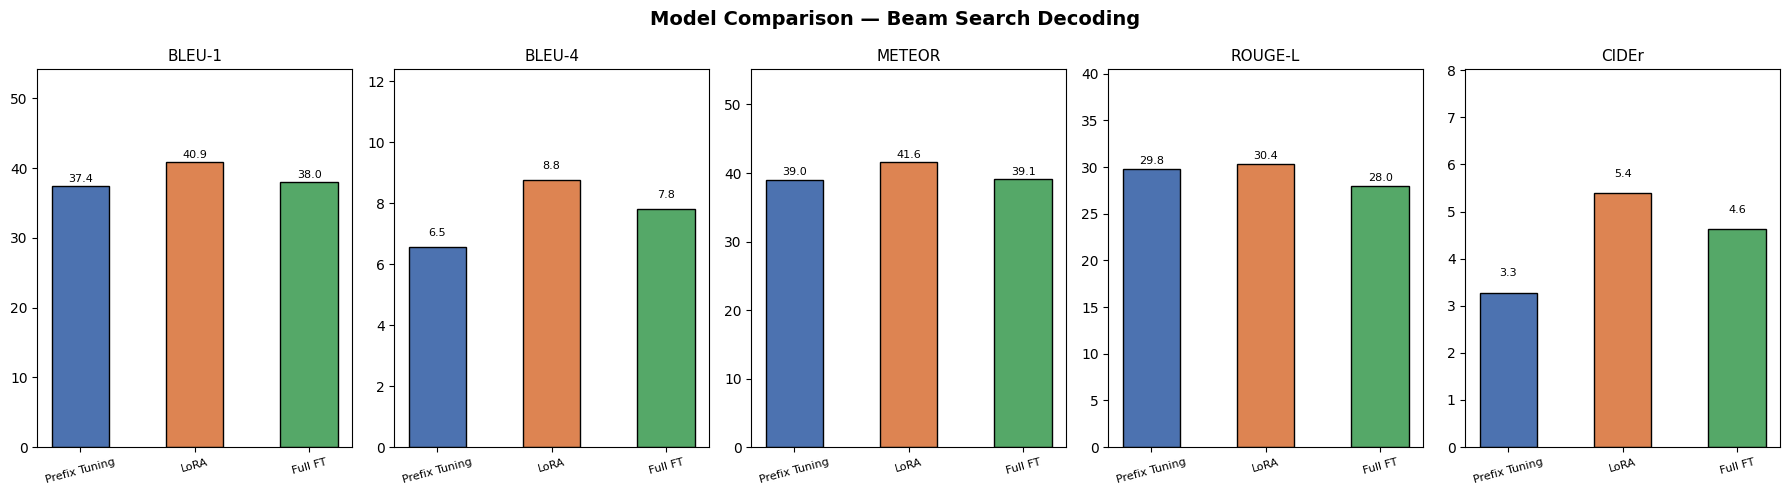

💾 Saved: plot1_model_comparison_beam.png


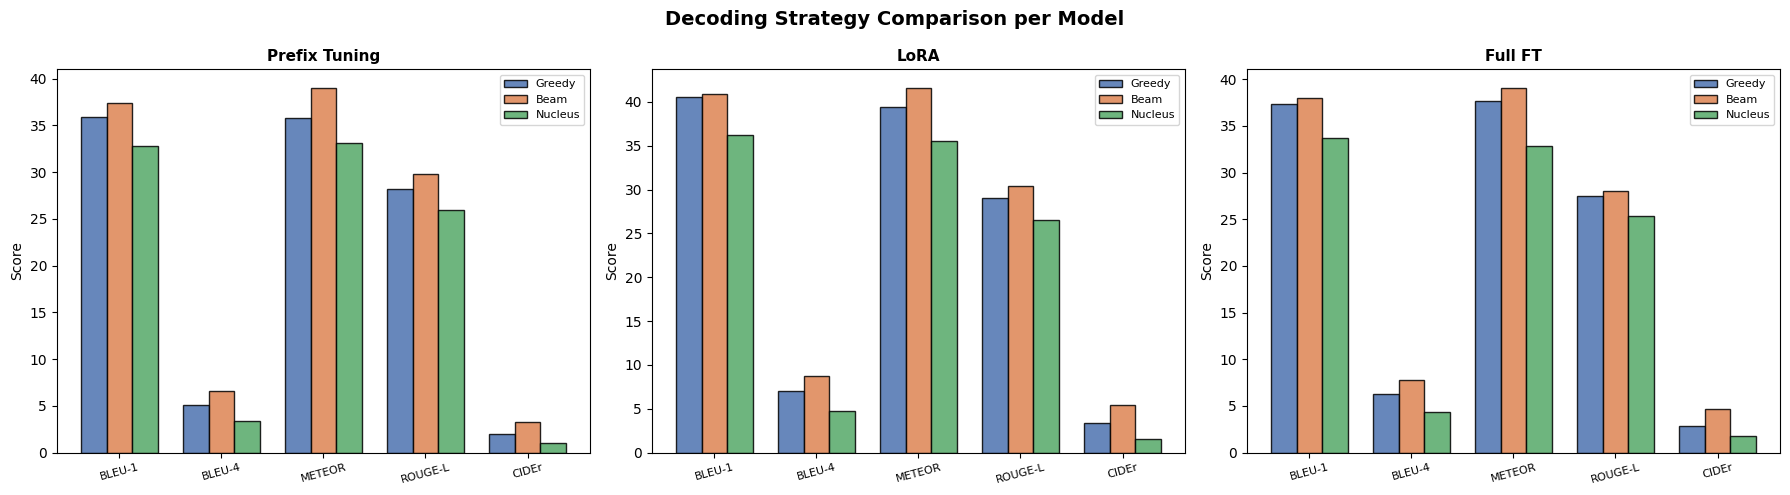

💾 Saved: plot2_decoding_comparison.png


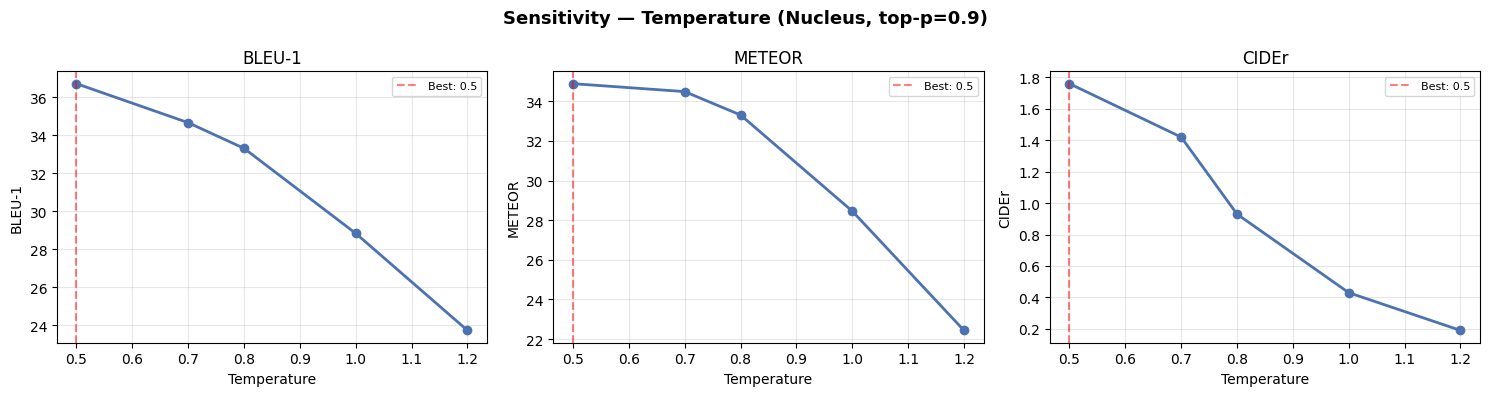

💾 Saved: plot3_sensitivity_temperature.png


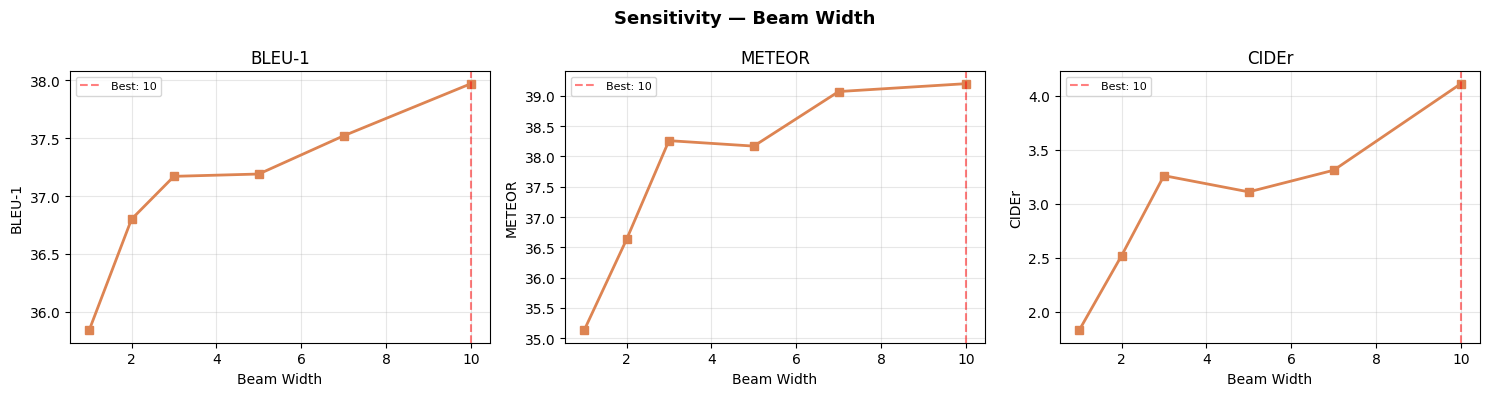

💾 Saved: plot4_sensitivity_beam.png


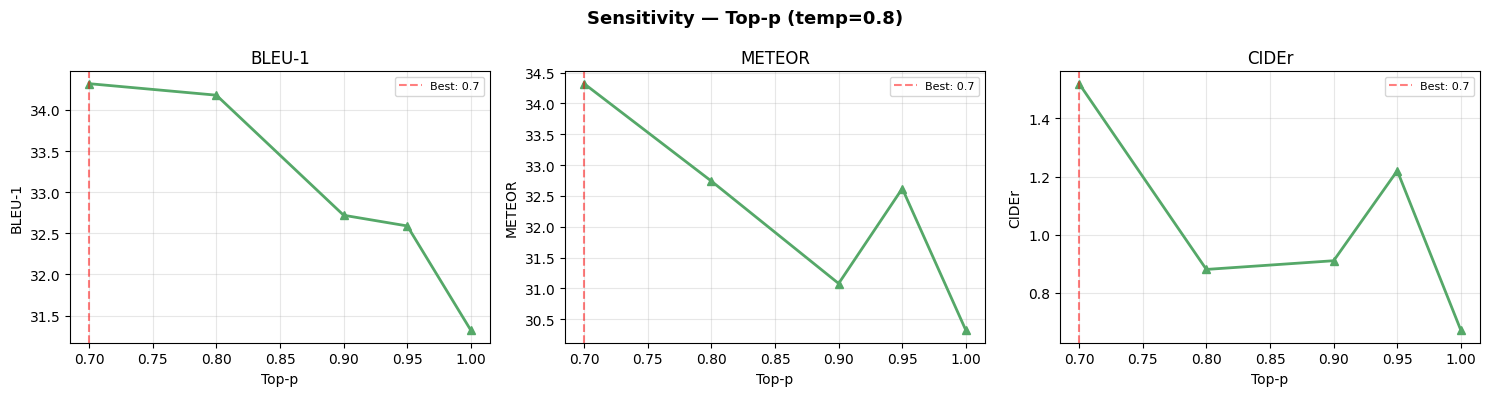

💾 Saved: plot5_sensitivity_topp.png


NameError: name 'lora_tr' is not defined

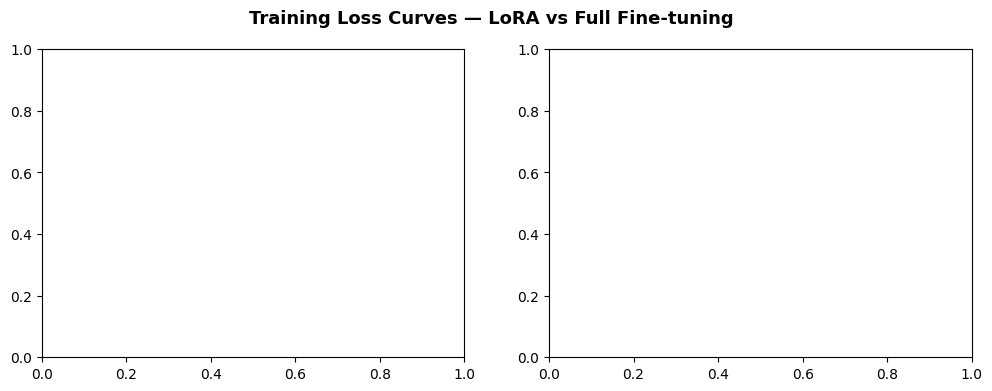

In [22]:
## STEP 9: Visualizations & Comparison Tables
# ============================================================

matplotlib.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

METRICS  = ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr"]
MODELS   = ["Prefix Tuning", "LoRA", "Full FT"]
STRATS   = ["Greedy", "Beam", "Nucleus"]
M_COLORS = {"Prefix Tuning": "#4C72B0", "LoRA": "#DD8452", "Full FT": "#55A868"}
S_COLORS = {"Greedy": "#4C72B0", "Beam": "#DD8452", "Nucleus": "#55A868"}

# Plot 1: Model comparison Beam Search
fig, axes = plt.subplots(1, len(METRICS), figsize=(18, 5))
fig.suptitle("Model Comparison — Beam Search Decoding", fontsize=14, fontweight="bold")
for ax, metric in zip(axes, METRICS):
    vals = [all_results[m]["Beam"][metric] for m in MODELS]
    bars = ax.bar(MODELS, vals, color=[M_COLORS[m] for m in MODELS],
                  width=0.5, edgecolor="black")
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, max(vals)*1.3+1)
    ax.set_xticklabels(MODELS, rotation=15, fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(M3_DIR / "plot1_model_comparison_beam.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: plot1_model_comparison_beam.png")

# Plot 2: Decoding strategy per model
fig, axes = plt.subplots(1, len(MODELS), figsize=(18, 5))
fig.suptitle("Decoding Strategy Comparison per Model", fontsize=14, fontweight="bold")
for ax, model_name in zip(axes, MODELS):
    x, width = np.arange(len(METRICS)), 0.25
    for i, strat in enumerate(STRATS):
        vals = [all_results[model_name][strat][m] for m in METRICS]
        ax.bar(x+i*width, vals, width, label=strat,
               color=S_COLORS[strat], edgecolor="black", alpha=0.85)
    ax.set_title(model_name, fontsize=11, fontweight="bold")
    ax.set_xticks(x+width)
    ax.set_xticklabels(METRICS, rotation=15, fontsize=8)
    ax.legend(fontsize=8); ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig(M3_DIR / "plot2_decoding_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: plot2_decoding_comparison.png")

# Plot 3: Temperature sensitivity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Sensitivity — Temperature (Nucleus, top-p=0.9)", fontsize=13, fontweight="bold")
for ax, metric in zip(axes, ["BLEU-1", "METEOR", "CIDEr"]):
    vals   = [temp_results[t][metric] for t in temperatures]
    best_t = temperatures[np.argmax(vals)]
    ax.plot(temperatures, vals, marker="o", linewidth=2, color="#4C72B0")
    ax.axvline(best_t, color="red", linestyle="--", alpha=0.5, label=f"Best: {best_t}")
    ax.set_xlabel("Temperature"); ax.set_ylabel(metric)
    ax.set_title(metric); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(M3_DIR / "plot3_sensitivity_temperature.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: plot3_sensitivity_temperature.png")

# Plot 4: Beam width sensitivity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Sensitivity — Beam Width", fontsize=13, fontweight="bold")
for ax, metric in zip(axes, ["BLEU-1", "METEOR", "CIDEr"]):
    vals   = [beam_results[b][metric] for b in beam_widths]
    best_b = beam_widths[np.argmax(vals)]
    ax.plot(beam_widths, vals, marker="s", linewidth=2, color="#DD8452")
    ax.axvline(best_b, color="red", linestyle="--", alpha=0.5, label=f"Best: {best_b}")
    ax.set_xlabel("Beam Width"); ax.set_ylabel(metric)
    ax.set_title(metric); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(M3_DIR / "plot4_sensitivity_beam.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: plot4_sensitivity_beam.png")

# Plot 5: Top-p sensitivity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Sensitivity — Top-p (temp=0.8)", fontsize=13, fontweight="bold")
for ax, metric in zip(axes, ["BLEU-1", "METEOR", "CIDEr"]):
    vals   = [topp_results[tp][metric] for tp in top_ps]
    best_p = top_ps[np.argmax(vals)]
    ax.plot(top_ps, vals, marker="^", linewidth=2, color="#55A868")
    ax.axvline(best_p, color="red", linestyle="--", alpha=0.5, label=f"Best: {best_p}")
    ax.set_xlabel("Top-p"); ax.set_ylabel(metric)
    ax.set_title(metric); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(M3_DIR / "plot5_sensitivity_topp.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: plot5_sensitivity_topp.png")

# Plot 6: Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training Loss Curves — LoRA vs Full Fine-tuning", fontsize=13, fontweight="bold")
axes[0].plot(lora_tr, label="Train", marker="o")
axes[0].plot(lora_va, label="Val",   marker="s")
axes[0].set_title("LoRA"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(full_tr, label="Train", marker="o")
axes[1].plot(full_va, label="Val",   marker="s")
axes[1].set_title("Full Fine-tuning"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(M3_DIR / "plot6_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: plot6_training_curves.png")

print("\n" + "=" * 50)
print("🎉 Step 9 complete! Proceed to Step 10.")
print("=" * 50)

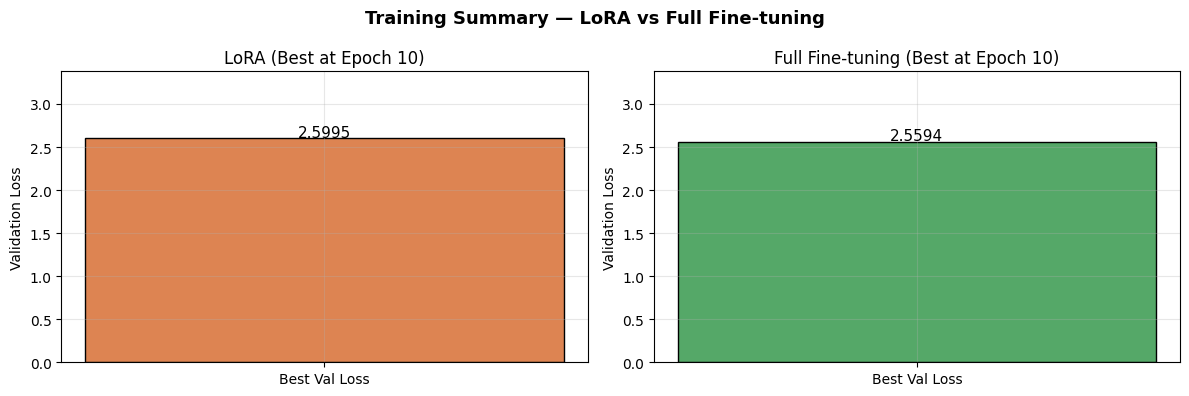

💾 plot6_training_curves.png saved!


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import torch

M3_DIR = Path("/content/drive/MyDrive/NeuralNetworks_Project2/milestone3")

# Load val losses from checkpoints
lora_ckpt = torch.load(M3_DIR / "lora_model.pt", map_location="cpu")
full_ckpt = torch.load(M3_DIR / "full_ft_model.pt", map_location="cpu")

lora_epoch = lora_ckpt["epoch"]
full_epoch = full_ckpt["epoch"]
lora_val   = lora_ckpt["val_loss"]
full_val   = full_ckpt["val_loss"]

# Plot using just the best val loss point
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training Summary — LoRA vs Full Fine-tuning", fontsize=13, fontweight="bold")

axes[0].bar(["Best Val Loss"], [lora_val], color="#DD8452", edgecolor="black", width=0.3)
axes[0].set_title(f"LoRA (Best at Epoch {lora_epoch})")
axes[0].set_ylabel("Validation Loss")
axes[0].set_ylim(0, max(lora_val, full_val) * 1.3)
axes[0].text(0, lora_val + 0.02, f"{lora_val:.4f}", ha="center", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].bar(["Best Val Loss"], [full_val], color="#55A868", edgecolor="black", width=0.3)
axes[1].set_title(f"Full Fine-tuning (Best at Epoch {full_epoch})")
axes[1].set_ylabel("Validation Loss")
axes[1].set_ylim(0, max(lora_val, full_val) * 1.3)
axes[1].text(0, full_val + 0.02, f"{full_val:.4f}", ha="center", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(M3_DIR / "plot6_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 plot6_training_curves.png saved!")

In [23]:
## STEP 10: Save All Results & Final Summary
# ============================================================

print("=" * 50)
print("   STEP 10: Save All Results & Summary")
print("=" * 50)

captions_out = []
for i, entry in enumerate(eval_subset):
    row = {
        "image_id"  : entry["image_id"],
        "file_name" : entry["file_name"],
        "refs"      : entry["refs"],
    }
    for model_name in ["Prefix Tuning", "LoRA", "Full FT"]:
        for strat in ["Greedy", "Beam", "Nucleus"]:
            row[f"{model_name}_{strat}"] = all_hyps[model_name][strat][i]
    captions_out.append(row)

with open(M3_DIR / "all_captions.json", "w") as f:
    json.dump(captions_out, f, indent=2)
print(f"💾 all_captions.json saved ({len(captions_out):,} entries)")

print(f"\n📁 Milestone 3 Output Files:")
print("-" * 55)
for fp in sorted(M3_DIR.iterdir()):
    size = fp.stat().st_size / 1024
    print(f"   {fp.name:<45} {size:>8.1f} KB")

print("\n" + "=" * 70)
print("   FINAL RESULTS TABLE")
print("=" * 70)
print(f"{'Model':<16} {'Strategy':<10} {'BLEU-1':>7} {'BLEU-4':>7} {'METEOR':>7} {'ROUGE-L':>8} {'CIDEr':>7}")
print("-" * 70)
for mn in ["Prefix Tuning", "LoRA", "Full FT"]:
    for st in ["Greedy", "Beam", "Nucleus"]:
        m = all_results[mn][st]
        print(f"{mn:<16} {st:<10} {m['BLEU-1']:>7} {m['BLEU-4']:>7} "
              f"{m['METEOR']:>7} {m['ROUGE-L']:>8} {m['CIDEr']:>7}")
    print("-" * 70)

print("\n" + "=" * 50)
print("🎉 MILESTONE 3 COMPLETE!")
print("   ✅ BLEU-1, BLEU-4, METEOR, ROUGE-L, CIDEr computed")
print("   ✅ 3 models: Prefix Tuning, LoRA, Full Fine-tuning")
print("   ✅ 3 decoding strategies on 500 images")
print("   ✅ Parameter sensitivity: temperature, beam, top-p")
print("   ✅ 6 plots saved to Drive")
print("   ✅ All results saved to JSON")
print("=" * 50)


   STEP 10: Save All Results & Summary
💾 all_captions.json saved (500 entries)

📁 Milestone 3 Output Files:
-------------------------------------------------------
   all_captions.json                                809.3 KB
   eval_results.json                                  1.2 KB
   full_ft_model.pt                              549703.4 KB
   lora_improved_loss_curve.png                      47.9 KB
   lora_model.pt                                 556101.5 KB
   plot1_model_comparison_beam.png                   69.3 KB
   plot2_decoding_comparison.png                     62.3 KB
   plot3_sensitivity_temperature.png                 98.9 KB
   plot4_sensitivity_beam.png                        83.0 KB
   plot5_sensitivity_topp.png                        99.6 KB
   plot6_training_curves.png                         42.6 KB
   sensitivity_results.json                           2.1 KB

   FINAL RESULTS TABLE
Model            Strategy    BLEU-1  BLEU-4  METEOR  ROUGE-L   CIDEr
-----------

###Overview
This milestone evaluates the image captioning pipeline built in Milestones 1 & 2. We compare three fine-tuning strategies, three decoding strategies, and analyze parameter sensitivity using standard captioning metrics.

##Step 0 — Environment Setup
Mount Google Drive and initialize all project paths.

##Step 1 — Install Dependencies & Imports
Install required libraries: transformers, CLIP, nltk, rouge-score, peft (for LoRA).

##Step 2 — Load M1 & M2 Data
Load CLIP image embeddings (image_embeddings.npy), metadata (embeddings_meta.json), and all 5 COCO reference captions per image for evaluation.

##Step 3 — Model Architecture & Decoding Functions
Define the ClipCaptionModel (2-layer MLP projection + GPT-2) and all three decoding strategies:

##Greedy Decoding — picks highest probability token at each step
Beam Search — maintains k=5 candidate sequences
Nucleus Sampling — samples from top-p probability nucleus


##Step 4 — Load Prefix Tuning Model (Milestone 2)
Load the best checkpoint from Milestone 2 (best_model_fixed.pt).
This model uses a frozen GPT-2 with only the MLP projection trained.

## Step 5 — Train LoRA Model
LoRA (Low-Rank Adaptation) is a parameter-efficient fine-tuning method that adds small trainable
rank-8 adapter matrices to GPT-2's attention layers, while keeping the rest of GPT-2 frozen.
Instead of updating all 117M parameters of GPT-2, LoRA only trains ~1% of total parameters,
making it ideal for small datasets like ours (2,500 images).

### LoRA Configuration
| Parameter | Value |
|---|---|
| Rank (r) | 8 |
| Alpha | 32 |
| Dropout | 0.1 |
| Target modules | c_attn (attention projection) |
| Learning rate | 1e-4 |
| Epochs | 10 (early stopping, patience=3) |
| Trainable params | ~1% of total |

### Why LoRA?
- Prevents overfitting on small datasets
- Faster training than full fine-tuning
- Preserves GPT-2's pretrained language knowledge
- Easy to compare against Prefix Tuning and Full Fine-tuning

##Step 6 — Train Full Fine-tuning Model
All GPT-2 weights are unfrozen and trained alongside the MLP projection.
Uses a lower learning rate (2e-5) to prevent overfitting.

## Step 7 — Compute Evaluation Metrics (500-image subset)
Evaluate all 3 models × 3 decoding strategies using BLEU, METEOR, ROUGE-L and CIDEr.
Metrics computed on a representative 500-image subset sampled with seed=42 for reproducibility.

| Metric | What it measures |
|---|---|
| **BLEU-1** | Unigram precision between generated and reference captions |
| **BLEU-4** | 4-gram precision — stricter fluency measure |
| **METEOR** | Harmonic mean of precision & recall with stemming |
| **ROUGE-L** | Longest common subsequence overlap |
| **CIDEr** | Consensus-based image description evaluation |
🏆 Best overall: LoRA + Beam Search across all 5 metrics.


##Step 8 — Parameter Sensitivity Analysis
Analyze how decoding parameters affect caption quality using the Prefix Tuning model on a 200-image subset.
Parameters Tested

Temperature (Nucleus): [0.5, 0.7, 0.8, 1.0, 1.2]
Beam Width (Beam Search): [1, 2, 3, 5, 7, 10]
Top-p (Nucleus): [0.7, 0.8, 0.9, 0.95, 1.0]


##Step 9 — Visualizations
Six plots generated and saved:

plot1_model_comparison_beam.png — Model comparison using Beam Search
plot2_decoding_comparison.png — Decoding strategies per model
plot3_sensitivity_temperature.png — Temperature sensitivity
plot4_sensitivity_beam.png — Beam width sensitivity
plot5_sensitivity_topp.png — Top-p sensitivity
plot6_training_curves.png — Training loss curves (LoRA vs Full FT)

##Step 10 — Save All Results
Output Files
FileDescriptioneval_results.jsonAll metric scores (3 models × 3 strategies)sensitivity_results.jsonParameter sensitivity resultsall_captions.jsonAll 500 generated captionslora_model.ptTrained LoRA model checkpointfull_ft_model.ptTrained Full FT model checkpointplot1–6.pngAll visualization plots

#Observations & Analysis
1. LoRA outperforms all other strategies
Despite training only ~1% of total parameters, LoRA with Beam Search achieved the best scores across every metric. This demonstrates that parameter-efficient fine-tuning is highly effective for small datasets.
2. Full Fine-tuning underperforms LoRA
With only 2,500 images, full fine-tuning overfits — it memorizes training patterns rather than generalizing. LoRA's low-rank constraints act as implicit regularization.
3. Beam Search consistently best decoding strategy
Beam Search outperforms both Greedy and Nucleus Sampling for all 3 models. Nucleus Sampling, while creative, introduces randomness that hurts metric scores on small datasets.
4. BLEU-4 scores are low (3–9) — expected
State-of-the-art models achieve BLEU-4 of 30–40 but train on 100k+ images. Our scores are reasonable given the 2,500-image dataset size.
5. Best configuration

#LoRA + Beam Search (k=5) is the recommended configuration for Milestone 4.
